In [1]:
import os
import io
import glob

import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl

from doppler import calculate_doppler_beta, calculate_doppler_energy
from pykinematic import calculate_kinematics, energy_to_beta, excitation_energy, recoil_kinematics

from lmfit.models import GaussianModel

level_energy = 3.72419 # MeV
gamma_energy = 1041 # keV
beta_mean = 0.067 # c units

theta_range = 30 # Define theta range for projection
theta_step = 7  # Number of bins on each side of the peak

theta_offset = 1.5
gain_factor = 1.03

tolerance = 100 # keV
tolerance_dc = 5 # keV

# Open 15O_Lifetime_AGATA_{gamma_energy}.npz and load the dataset
dataset = np.load(f"data/15O_Lifetime_AGATA_{gamma_energy}.npz", allow_pickle=True)

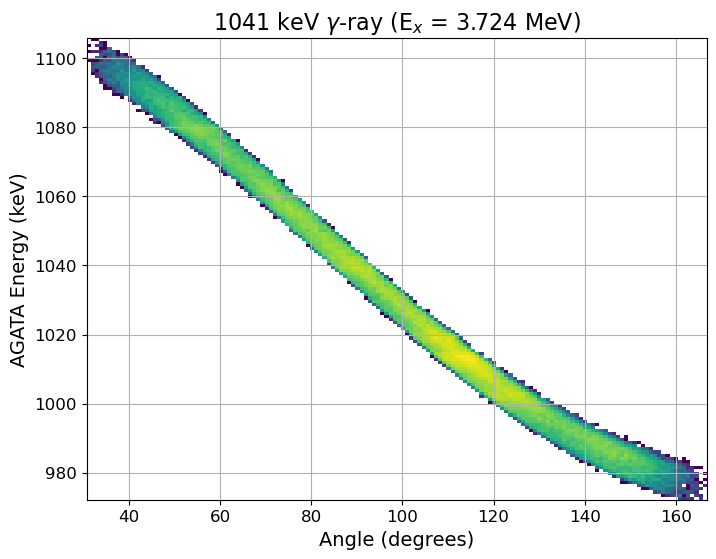

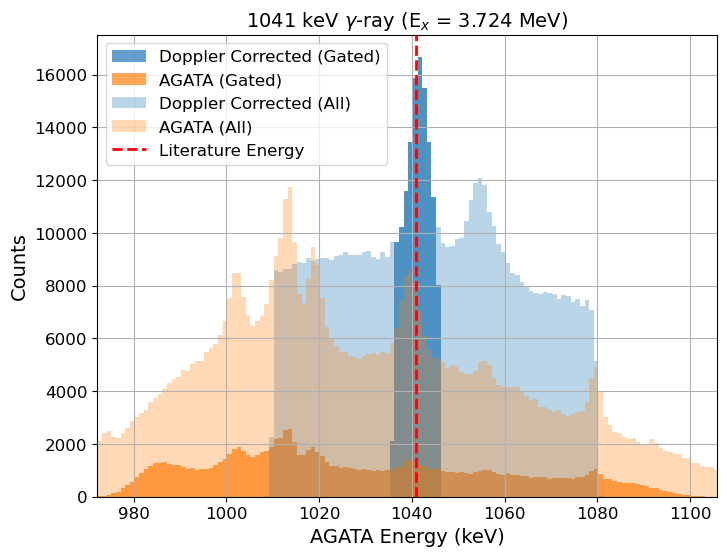

In [2]:
# Calculate Doppler energies
theta_grid = np.linspace(0, 180, 100)  # Example theta grid for plotting
doppler_energies = calculate_doppler_energy(gamma_energy, beta_mean, theta_grid)

# Get the raw data arrays from the dataset
energy_agata_raw = dataset["energy_agata"]
energy_agata_dc_raw = dataset["energy_agata_dc"]
theta_agata_sauron_raw = dataset["theta_agata_sauron"]
beta_agata_raw = dataset["beta_agata"]
energy_reac_raw = dataset["energy_reac"]
energy_ex_raw = dataset["energy_ex"]
energy_binary_raw = dataset["energy_binary"]
beta_reaction_raw = dataset["beta_reaction"]
theta_binary_raw = dataset["theta_binary"]
theta_reac_sauron_raw = dataset["theta_reac_sauron"]

# Loop on all the events and select best ones
energies_agata_all = []
energies_agata = []
energies_agata_dc_all = []
energies_agata_dc = []
beta_emission = []
thetas = []
thetas_all = []
event_indices = []
event_indices_all = []

# The AGATA data might have more than 1 event: we select the closest one to the Doppler curve
for evt_idx, (ene_evt, ene_dc_evt, theta_evt, beta_evt) in enumerate(zip(energy_agata_raw, energy_agata_dc_raw, theta_agata_sauron_raw, beta_agata_raw)):
    
    # If blank, skip
    if len(ene_evt) == 0: continue
    
    # Interpolate the Doppler curve at the given theta values
    calculated_energies = np.interp( np.rad2deg( theta_evt ), theta_grid, doppler_energies )
    
    # Find the index of the closest point on the Doppler curve
    idx = np.argmin( np.abs( ene_evt - calculated_energies ) )
    
    # Calculate the distance to the Doppler curve and the DC energy
    distance = np.abs( ene_evt[idx] - calculated_energies[idx])
    distance_dc = np.abs( ene_dc_evt[idx] - gamma_energy )
    
    # If both distances are within the tolerance, select the event
    if distance < tolerance and distance_dc < tolerance_dc:
        energies_agata.append(ene_evt[idx])
        energies_agata_dc.append(ene_dc_evt[idx])
        beta_emission.append(beta_evt[idx])
        thetas.append(np.rad2deg(theta_evt[idx]))
        event_indices.append(evt_idx)

    energies_agata_all.append(ene_evt[idx])
    energies_agata_dc_all.append(ene_dc_evt[idx])
    event_indices_all.append(evt_idx)

# Now mask the others arrays with the selected events
selected_energies = np.array(energies_agata)
selected_energies_dc = np.array(energies_agata_dc)
selected_thetas = np.array(thetas)
selected_beta_emission = np.array(beta_emission)
selected_energy_reac = energy_reac_raw[event_indices]
selected_energy_binary = energy_binary_raw[event_indices]
selected_theta_reac_sauron = np.rad2deg(theta_reac_sauron_raw[event_indices])
selected_beta_reaction = beta_reaction_raw[event_indices]
selected_theta_binary = np.rad2deg(theta_binary_raw[event_indices])
selected_energy_ex = energy_ex_raw[event_indices]

# Create the figure
plt.figure(figsize=(8, 6))

plt.hist2d(selected_thetas, selected_energies, bins=[150, 150], cmap="viridis", norm=mpl.colors.LogNorm())
#plt.plot(theta_grid, doppler_energies, color="red", label="Doppler Curve", linewidth=2, linestyle="--", zorder=1)

#plt.colorbar(label="Counts")

plt.xlabel("Angle (degrees)", fontsize=14)
plt.ylabel("AGATA Energy (keV)", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.title(f"{gamma_energy} keV $\\gamma$-ray (E$_x$ = {level_energy:.3f} MeV)", fontsize=16)
plt.grid()

plt.savefig(f"plots/agata_theta_{gamma_energy}.png", dpi=300)
plt.show()

# Plot DC energy histogram for the selected events
plt.figure(figsize=(8, 6))

#min_x, max_x = np.min(selected_energies), np.max(selected_energies)
min_x, max_x = np.min(selected_energies), np.max(selected_energies)
bin_width = 1.0 # keV
bins = np.arange(min_x, max_x + bin_width, bin_width)

plt.hist(selected_energies_dc, bins=bins, range=(min_x, max_x), alpha=0.7, color="tab:blue", label="Doppler Corrected (Gated)")
plt.hist(selected_energies, bins=bins, range=(min_x, max_x), alpha=0.7, color="tab:orange", label="AGATA (Gated)")
plt.hist(energies_agata_dc_all, bins=bins, range=(min_x, max_x), alpha=0.3, color="tab:blue", label="Doppler Corrected (All)")
plt.hist(energies_agata_all, bins=bins, range=(min_x, max_x), alpha=0.3, color="tab:orange", label="AGATA (All)")
plt.axvline(gamma_energy, color="red", label="Literature Energy", linestyle="--", linewidth=2)

plt.xlabel("AGATA Energy (keV)", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.xlim(min_x, max_x)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.title(f"{gamma_energy} keV $\\gamma$-ray (E$_x$ = {level_energy:.3f} MeV)", fontsize=14)
plt.grid()

plt.legend(fontsize=12)

plt.savefig(f"plots/agatadc_theta_{gamma_energy}.png", dpi=300)
plt.show()

/var/folders/13/_3g2lmwx6xl3zshjv1d7yz4c0000gn/T/ipykernel_35196/254709474.py:39: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = plt.gca().get_legend_handles_labels()
/var/folders/13/_3g2lmwx6xl3zshjv1d7yz4c0000gn/T/ipykernel_35196/254709474.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"plots/kinematics_theta_{gamma_energy}.png", dpi=300)


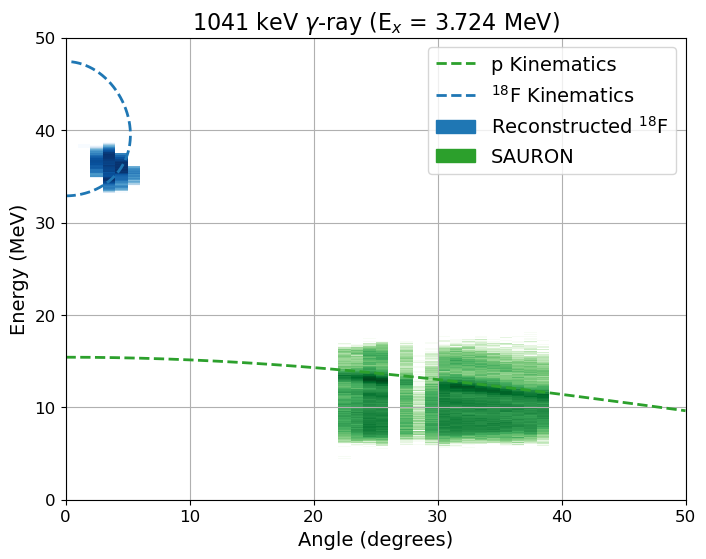

In [3]:
from matplotlib import patches as mpatches

# Calculate kinematics
data = calculate_kinematics(
            beam="16O",
            target="3He",
            ejectile="1H",
            recoil="18F",
            beam_energy=50,
            ex=level_energy,
            angle_step=0.1  # 1 degree step
        )

angles = np.array( data["theta_ejectile"] )
angles_binary = np.array( data["theta_recoil"] )
energies = np.array( data["energy_ejectile"] )
energies_binary = np.array( data["energy_recoil"] )
mask = (energies > 5)

# Plot EneReacA vs ThetaReacSau for selected events
plt.figure(figsize=(8, 6))
plt.hist2d(selected_theta_reac_sauron, selected_energy_reac, bins=[60, 1000], range=[[0, 60], [0, 60]], cmap="Greens", norm=mpl.colors.LogNorm(), label="SAURON")
plt.hist2d(selected_theta_binary, selected_energy_binary, bins=[60, 1000], range=[[0, 60], [0, 60]], cmap="Blues", norm=mpl.colors.LogNorm(), label="Reconstructed Binary")
plt.plot(angles, energies, color="tab:green", label="p Kinematics", linewidth=2, linestyle="--")
plt.plot(angles_binary, energies_binary, color="tab:blue", label=r"$^{18}$F Kinematics", linewidth=2, linestyle="--")

plt.xlabel("Angle (degrees)", fontsize=14)
plt.ylabel("Energy (MeV)", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlim(0, 50)
plt.ylim(0, 50)

plt.title(f"{gamma_energy} keV $\\gamma$-ray (E$_x$ = {level_energy:.3f} MeV)", fontsize=16)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(mpatches.Patch(color='tab:blue', label='2D histogram'))
handles.append(mpatches.Patch(color='tab:green', label='2D histogram'))
labels.append(r'Reconstructed $^{18}$F')
labels.append(r'SAURON')
plt.legend(handles=handles, labels=labels, fontsize=14)

plt.savefig(f"plots/kinematics_theta_{gamma_energy}.png", dpi=300)
plt.show()

/var/folders/13/_3g2lmwx6xl3zshjv1d7yz4c0000gn/T/ipykernel_35196/857292966.py:95: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"plots/kinematics_theta_{gamma_energy}_corrected.png", dpi=300)


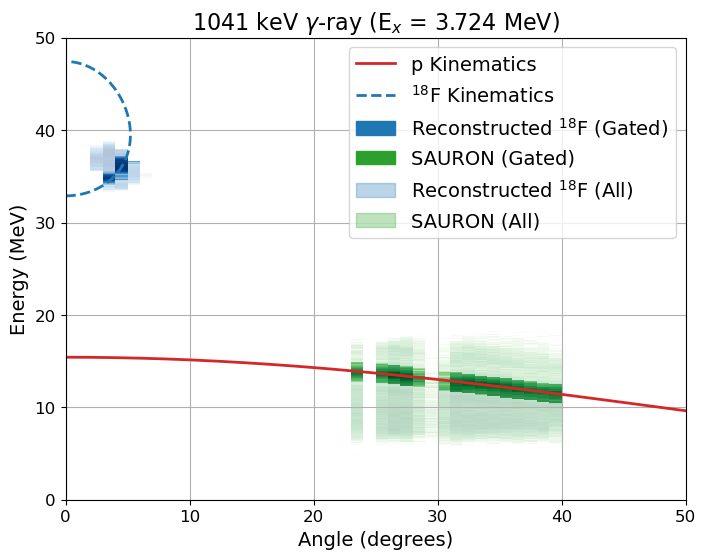

In [4]:
# Interpolate the expected energy from the kinematic line at each data point's angle
expected_energy = np.interp(selected_theta_reac_sauron, angles[mask] - theta_offset, energies[mask] / gain_factor)  # Adjust angles and energies for the offset and gain

# Define a window around the kinematic line (e.g., ±3 MeV)
delta = 1.0  # MeV, adjust as needed

# Mask: keep only events within delta of the kinematic curve
kin_mask = np.abs(selected_energy_reac - expected_energy) < delta

# Save previous data
all_theta_sauron = selected_theta_reac_sauron.copy() + theta_offset
all_energy_sauron = selected_energy_reac.copy() * gain_factor

# Apply the masks
masked_theta = selected_theta_reac_sauron[kin_mask]
masked_energy = selected_energy_reac[kin_mask]

# Now mask when selected_theta_reac_sauron is > 10 and < 15
selected_energies = selected_energies[kin_mask]
selected_energies_dc = selected_energies_dc[kin_mask]
selected_thetas = selected_thetas[kin_mask]
selected_beta_emission = selected_beta_emission[kin_mask]
selected_energy_reac = selected_energy_reac[kin_mask] * gain_factor
selected_energy_binary = selected_energy_binary[kin_mask]
selected_theta_reac_sauron = selected_theta_reac_sauron[kin_mask] + theta_offset
selected_beta_reaction = selected_beta_reaction[kin_mask]
selected_theta_binary = selected_theta_binary[kin_mask]
selected_energy_ex = selected_energy_ex[kin_mask]

data = recoil_kinematics(
            beam="16O",
            target="3He",
            ejectile="1H",
            recoil="18F",
            beam_energy=50,
            ex=level_energy,
            ejectile_energy=selected_energy_reac,
            angle=selected_theta_reac_sauron
        )

data_all = recoil_kinematics(
            beam="16O",
            target="3He",
            ejectile="1H",
            recoil="18F",
            beam_energy=50,
            ex=level_energy,
            ejectile_energy=all_energy_sauron,
            angle=all_theta_sauron
        )

all_energies_bin = data_all[0]
all_angles_bin = data_all[1]

new_energies = data[0]
new_angles = data[1]

selected_energy_binary = new_energies
selected_theta_binary = new_angles
for i in range(len(selected_energy_binary)):
    selected_beta_reaction[i] = energy_to_beta( selected_energy_binary[i], 18 * 931.5)

    # Plot EneReacA vs ThetaReacSau for selected events
plt.figure(figsize=(8, 6))
plt.hist2d(selected_theta_reac_sauron, selected_energy_reac, bins=[60, 1000], range=[[0, 60], [0, 60]], cmap="Greens", norm=mpl.colors.LogNorm())
plt.hist2d(selected_theta_binary, selected_energy_binary, bins=[60, 1000], range=[[0, 60], [0, 60]], cmap="Blues", norm=mpl.colors.LogNorm())
plt.hist2d(all_theta_sauron, all_energy_sauron, bins=[60, 1000], range=[[0, 60], [0, 60]], cmap="Greens", norm=mpl.colors.LogNorm(), alpha=0.3)
plt.hist2d(all_angles_bin, all_energies_bin, bins=[60, 1000], range=[[0, 60], [0, 60]], cmap="Blues", norm=mpl.colors.LogNorm(), alpha=0.3)
plt.plot(angles, energies, color="tab:red", label="p Kinematics", linewidth=2, linestyle="-")
plt.plot(angles_binary, energies_binary, color="tab:blue", label=r"$^{18}$F Kinematics", linewidth=2, linestyle="--")

plt.xlabel("Angle (degrees)", fontsize=14)
plt.ylabel("Energy (MeV)", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlim(0, 50)
plt.ylim(0, 50)

plt.title(f"{gamma_energy} keV $\\gamma$-ray (E$_x$ = {level_energy:.3f} MeV)", fontsize=16)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(mpatches.Patch(color='tab:blue', label='2D histogram'))
handles.append(mpatches.Patch(color='tab:green', label='2D histogram'))
handles.append(mpatches.Patch(color='tab:blue', label='2D histogram', alpha=0.3))
handles.append(mpatches.Patch(color='tab:green', label='2D histogram', alpha=0.3))
labels.append(r'Reconstructed $^{18}$F (Gated)')
labels.append(r'SAURON (Gated)')
labels.append(r'Reconstructed $^{18}$F (All)')
labels.append(r'SAURON (All)')
plt.legend(handles=handles, labels=labels, fontsize=14)

plt.savefig(f"plots/kinematics_theta_{gamma_energy}_corrected.png", dpi=300)
plt.show()

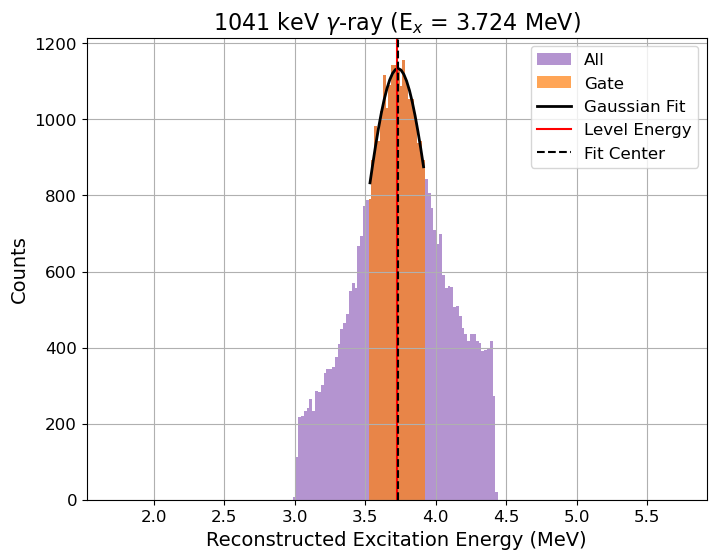

Fit Center: 3.73250 MeV
Level Energy: 3.72419 MeV
Percentage Difference: 0.22%


In [5]:
excitation = excitation_energy(
          beam="16O",
          target="3He",
          ejectile="1H",
          recoil="18F",
          beam_energy=50.0,
          ejectile_energy=selected_energy_reac,
          angle=selected_theta_reac_sauron
      )

excitation = np.array(excitation)

# Mask around 1 MeV
mask = (excitation > level_energy - 0.2) & (excitation < level_energy + 0.2)
selected_beta_emission = selected_beta_emission[mask]
selected_beta_reaction = selected_beta_reaction[mask]
selected_thetas = selected_thetas[mask]

min_x, max_x = level_energy - 2, level_energy + 2

# Do a gaussian fit to the excitation energy histogram
counts, bins = np.histogram(excitation, bins=200, range=(min_x, max_x))
bin_centers = (bins[:-1] + bins[1:]) / 2

# Mask around 0.2 MeV
mask_fit = (bin_centers > level_energy - 0.2) & (bin_centers < level_energy + 0.2)

model = GaussianModel()
params = model.guess(counts[mask_fit], x=bin_centers[mask_fit])
result = model.fit(counts[mask_fit], params, x=bin_centers[mask_fit])

plt.figure(figsize=(8, 6))

plt.hist(excitation, bins=200, range=(min_x, max_x), color="tab:purple", alpha=0.7, label="All")
plt.hist(excitation[mask], bins=200, range=(min_x, max_x), color="tab:orange", alpha=0.7, label="Gate")
plt.plot(bin_centers[mask_fit], result.best_fit, color="black", label="Gaussian Fit", linewidth=2)
plt.axvline(level_energy, color="red", linestyle="-", label=f"Level Energy")
plt.axvline(result.params['center'].value, color="black", linestyle="--", label=f"Fit Center")

plt.xlabel("Reconstructed Excitation Energy (MeV)", fontsize=14)
plt.ylabel("Counts", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.title(f"{gamma_energy} keV $\\gamma$-ray (E$_x$ = {level_energy:.3f} MeV)", fontsize=16)

plt.grid()

plt.legend(fontsize=12)

plt.savefig(f"plots/excitation_energy_{gamma_energy}.png", dpi=300)
plt.show()

# Print percentage difference between fit center and level energy
percentage_diff = (result.params['center'].value - level_energy) / level_energy * 100
print(f"Fit Center: {result.params['center'].value:.5f} MeV")
print(f"Level Energy: {level_energy:.5f} MeV")
print(f"Percentage Difference: {percentage_diff:.2f}%")

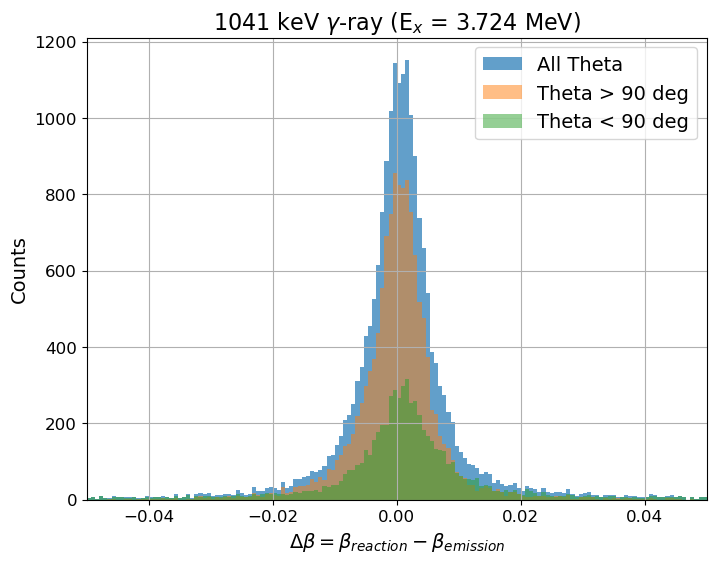

In [6]:
# Calculate delta beta
delta_beta = selected_beta_reaction - selected_beta_emission

# Plot 1D histograms of delta beta distributions
plt.figure(figsize=(8, 6))

plt.hist(delta_beta, bins=300, range=(-1e-1, 1e-1), alpha=0.7, label="All Theta")

# Now plot delta_betas > 90 deg and < 90 deg
mask = selected_thetas > 90
delta_beta_gt_90 = delta_beta[mask]
delta_beta_lt_90 = delta_beta[~mask]

plt.hist(delta_beta_gt_90, bins=300, range=(-1e-1, 1e-1), alpha=0.5, label="Theta > 90 deg")
plt.hist(delta_beta_lt_90, bins=300, range=(-1e-1, 1e-1), alpha=0.5, label="Theta < 90 deg")

plt.xlim(-1e-1, 1e-1)

plt.xlabel(r"$\Delta \beta = \beta _{reaction} - \beta _{emission}$", fontsize=14)
plt.ylabel("Counts", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlim(-0.05, 0.05)

plt.title(f"{gamma_energy} keV $\\gamma$-ray (E$_x$ = {level_energy:.3f} MeV)", fontsize=16)
plt.grid()

plt.legend(fontsize=14)

plt.show()

Skipping theta window [0.0, 30.0] - only 0 events
Skipping theta window [7.0, 37.0] - only 62 events
Valid windows: 18
Bootstrap: 50/200
Bootstrap: 100/200
Bootstrap: 150/200
Bootstrap: 200/200
Bootstrap: 200/200 complete samples across 18 windows


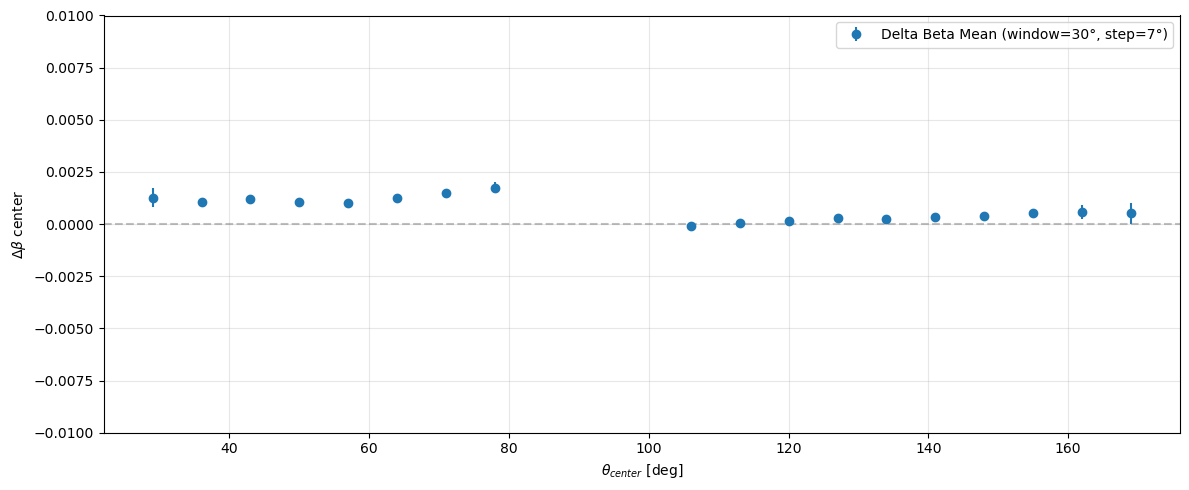


Total fits performed: 18
Theta range coverage: 29.0° - 169.0°


In [7]:
# Storage arrays
results = {
    'theta': [],
    'delta_beta': [],
    'delta_beta_error': [],
}

def gaussian(x, amplitude, center, sigma):
    return amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)

n_bootstrap = 200  # Number of bootstrap iterations

# Create sliding window positions
theta_starts = np.arange(0, 180 - theta_range + theta_step, theta_step)

# Delete all plots in "plots/temp/"
temp_plot_dir = "plots/temp/"
if not os.path.exists(temp_plot_dir):
    os.makedirs(temp_plot_dir)
else:
    files = glob.glob(os.path.join(temp_plot_dir, "*"))
    for f in files:
        os.remove(f)

# ── First pass: collect valid theta windows ────────────────────────────────
valid_windows = []
for theta_start in theta_starts:
    theta_min = theta_start
    theta_max = theta_start + theta_range
    theta_center = (theta_min + theta_max) / 2

    if 80 <= theta_center <= 100:
        continue

    mask = (selected_thetas >= theta_min) & (selected_thetas < theta_max)
    delta_beta_bin = delta_beta[mask]
    delta_beta_bin = delta_beta_bin[~np.isnan(delta_beta_bin)]
    if len(delta_beta_bin) < 100:
        print(f"Skipping theta window [{theta_min:.1f}, {theta_max:.1f}] - only {len(delta_beta_bin)} events")
        continue
    valid_windows.append(theta_center)

n_windows = len(valid_windows)
print(f"Valid windows: {n_windows}")

# ── Bootstrap resampling ───────────────────────────────────────────────────
all_indices = np.arange(len(delta_beta))
bootstrap_centers = np.full((n_bootstrap, n_windows), np.nan)

for boot_idx in range(n_bootstrap):
    if (boot_idx + 1) % 50 == 0:
        print(f"Bootstrap: {boot_idx + 1}/{n_bootstrap}")
    boot_idx_arr = np.random.choice(all_indices, size=len(all_indices), replace=True)
    boot_thetas  = selected_thetas[boot_idx_arr]
    boot_db      = delta_beta[boot_idx_arr]

    for win_idx, theta_center in enumerate(valid_windows):
        theta_min_w = theta_center - theta_range / 2
        theta_max_w = theta_center + theta_range / 2
        mask = (boot_thetas >= theta_min_w) & (boot_thetas < theta_max_w)
        db_bin = boot_db[mask]
        db_bin = db_bin[~np.isnan(db_bin)]
        if len(db_bin) < 50:
            continue
        hist, bin_edges = np.histogram(db_bin, bins=300, range=(-1e-1, 1e-1), density=False)
        bin_centers_h = (bin_edges[:-1] + bin_edges[1:]) / 2
        bw = bin_edges[1] - bin_edges[0]
        max_idx = np.argmax(hist)
        vb = hist > hist[max_idx] * 0.01
        x_d, y_d = bin_centers_h[vb], hist[vb]
        if len(x_d) < 3:
            continue
        try:
            mdl = GaussianModel()
            p   = mdl.make_params(amplitude=hist[max_idx] * bw * np.sqrt(2*np.pi) * np.std(db_bin),
                                  center=np.mean(db_bin), sigma=np.std(db_bin))
            res = mdl.fit(y_d, p, x=x_d, weights=1.0/np.sqrt(y_d + 1))
            bootstrap_centers[boot_idx, win_idx] = res.params['center'].value
        except Exception:
            pass

# ── Bootstrap covariance matrix ────────────────────────────────────────────
good_mask = np.array([np.sum(~np.isnan(bootstrap_centers[:, i])) >= 10 for i in range(n_windows)])
good_indices = np.where(good_mask)[0]
complete_rows = ~np.any(np.isnan(bootstrap_centers[:, good_indices]), axis=1)
print(f"Bootstrap: {complete_rows.sum()}/{n_bootstrap} complete samples across {len(good_indices)} windows")
sub_centers = bootstrap_centers[complete_rows][:, good_indices]
if sub_centers.shape[0] > 1 and len(good_indices) > 1:
    bootstrap_cov = np.cov(sub_centers.T)
else:
    bootstrap_cov = np.diag(np.nanvar(bootstrap_centers[:, good_indices], axis=0))

# ── Fit original data for diagnostic plots ─────────────────────────────────
for win_idx, theta_center in enumerate(valid_windows):
    theta_min_w = theta_center - theta_range / 2
    theta_max_w = theta_center + theta_range / 2
    mask = (selected_thetas >= theta_min_w) & (selected_thetas < theta_max_w)
    db_bin = delta_beta[mask]
    db_bin = db_bin[~np.isnan(db_bin)]
    hist, bin_edges = np.histogram(db_bin, bins=300, range=(-1e-1, 1e-1), density=False)
    bin_centers_h = (bin_edges[:-1] + bin_edges[1:]) / 2
    bw = bin_edges[1] - bin_edges[0]
    max_idx = np.argmax(hist)
    vb = hist > hist[max_idx] * 0.01
    x_d, y_d = bin_centers_h[vb], hist[vb]
    try:
        mdl = GaussianModel()
        p   = mdl.make_params(amplitude=hist[max_idx] * bw * np.sqrt(2*np.pi) * np.std(db_bin),
                              center=np.mean(db_bin), sigma=np.std(db_bin))
        res = mdl.fit(y_d, p, x=x_d, weights=1.0/np.sqrt(y_d + 1))
        plt.figure()
        plt.errorbar(bin_centers_h, hist, yerr=np.sqrt(hist + 1), fmt='o', label='Data', color='black')
        plt.plot(x_d, res.best_fit, label='Fit', zorder=9, color='red')
        plt.xlim(*(-1e-1, 1e-1))
        plt.xlabel(r'$\Delta\beta$')
        plt.ylabel('Counts')
        plt.title(f'Theta window: {theta_min_w:.1f} - {theta_max_w:.1f} (center: {theta_center:.1f}°)')
        plt.savefig(f"plots/temp/fit_theta_{theta_center:.1f}.png")
        plt.close()
    except Exception as e:
        print(f"Original fit failed for θ={theta_center:.1f}°: {e}")

# ── Store bootstrap-derived results ────────────────────────────────────────
for win_idx in good_indices:
    theta_center = valid_windows[win_idx]
    ci = bootstrap_centers[:, win_idx]
    vi = ~np.isnan(ci)
    results['theta'].append(theta_center)
    results['delta_beta'].append(np.mean(ci[vi]))
    results['delta_beta_error'].append(np.std(ci[vi]))

# Convert to numpy arrays
for key in results:
    results[key] = np.array(results[key])

# Plot results
plt.figure(figsize=(12, 5))
plt.errorbar(results['theta'], results['delta_beta'], yerr=results['delta_beta_error'],
             fmt='o', label=f'Delta Beta Mean (window={theta_range}°, step={theta_step}°)')
plt.ylim(-1e-2, 1e-2)
plt.xlabel(r'$\theta_{center}$ [deg]')
plt.ylabel(r'$\Delta\beta$ center')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal fits performed: {len(results['theta'])}")
if len(results['theta']) > 0:
    print(f"Theta range coverage: {results['theta'].min():.1f}° - {results['theta'].max():.1f}°")

np.savetxt("utils/delta_beta_vs_theta.txt",
           np.column_stack((results['theta'], results['delta_beta'], results['delta_beta_error'])),
           header="theta_center [deg]  delta_beta_center [rad]  delta_beta_error [rad]", fmt="%.6e")

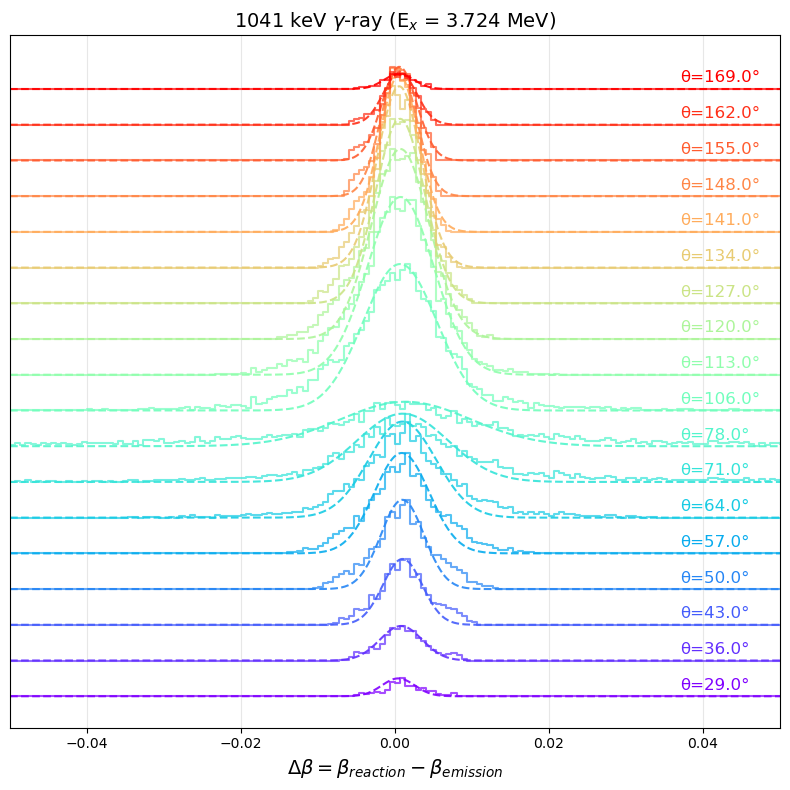

In [8]:
# ── Waterfall / stacked plot (reproducing old-style visualization) ──────────
import matplotlib.cm as cm

# Determine how many valid results we have and assign colors
n_results = len(results['theta'])

if n_results > 0:
    fig_wf, ax_wf = plt.subplots(figsize=(8, 8))

    # Sort results by theta so the color gradient is ordered
    sort_idx = np.argsort(results['theta'])
    thetas_sorted  = results['theta'][sort_idx]
    centers_sorted = results['delta_beta'][sort_idx]
    errors_sorted  = results['delta_beta_error'][sort_idx]

    colors = cm.rainbow(np.linspace(0, 1, n_results))

    # We need to re-create the per-window histograms to draw the step plots.
    # Collect (hist, bin_centers, popt, theta_center) for each window.
    hists_for_plot = []

    for idx, theta_center in enumerate(thetas_sorted):
        theta_min_w = theta_center - theta_range / 2
        theta_max_w = theta_center + theta_range / 2

        mask = (selected_thetas >= theta_min_w) & (selected_thetas < theta_max_w)
        db_bin = delta_beta[mask]
        db_bin = db_bin[~np.isnan(db_bin)]

        if len(db_bin) < 100:
            hists_for_plot.append(None)
            continue

        hist, bin_edges = np.histogram(db_bin, bins=300, range=(-1e-1, 1e-1), density=False)
        bin_centers_h = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Gaussian parameters from stored results
        center_val = centers_sorted[idx]
        # Reconstruct approximate popt using stored values
        # (amplitude from histogram peak, sigma from stored sigma if available)
        amplitude = np.max(hist)
        sigma_val  = np.std(db_bin)   # fallback; replace with stored sigma if you store it

        # Refit the Gaussian to get a smooth curve for plotting (optional, can be skipped if you trust the stored parameters)
        try:
            model = GaussianModel()
            params = model.make_params(
                amplitude=amplitude * bin_width * np.sqrt(2*np.pi) * sigma_val,
                center=center_val,
                sigma=sigma_val
            )
            x_data_fit = bin_centers_h[(hist > hist.max() * 0.5)]
            y_data_fit = hist[(hist > hist.max() * 0.5)]
            weights_fit = 1.0 / np.sqrt(y_data_fit + 1)
            result_fit = model.fit(y_data_fit, params, x=x_data_fit, weights=weights_fit)
            center_val = result_fit.params['center'].value
            sigma_val = result_fit.params['sigma'].value
        except:
            print(f"Refit failed for theta center {theta_center:.1f}°, using stored parameters")
            pass  # If fit fails, use the original parameters

        hists_for_plot.append((hist, bin_centers_h, amplitude, center_val, sigma_val))

    # Determine vertical offset scale from the first valid histogram
    offset_step = 0
    for entry in hists_for_plot:
        if entry is not None:
            offset_step = np.max(entry[0]) * 2
            break

    # Only show ~20 windows to avoid overcrowding (same logic as old code)
    plot_every = max(1, n_results // 20)

    for idx, entry in enumerate(hists_for_plot):
        if entry is None:
            continue

        hist, bin_centers_h, amplitude, center_val, sigma_val = entry
        vertical_offset = idx * offset_step
        color = colors[idx]

        if idx % plot_every == 0:
            # Step histogram
            ax_wf.step(bin_centers_h, hist + vertical_offset,
                       where='mid', color=color, linewidth=1.5, alpha=0.7)

            # Gaussian overlay
            x_fine = np.linspace(-1e-1, 1e-1, 1000)
            gauss_fine = amplitude * np.exp(-0.5 * ((x_fine - center_val) / sigma_val) ** 2)
            ax_wf.plot(x_fine, gauss_fine + vertical_offset,
                       color=color, linestyle='--', linewidth=1.5, alpha=0.9)

            # Theta label on the right side
            ax_wf.text(0.037, vertical_offset + offset_step * 0.1,
                       f'θ={thetas_sorted[idx]:.1f}°',
                       color=color, fontsize=12, verticalalignment='bottom')

    ax_wf.set_xlabel(r"$\Delta \beta = \beta _{reaction} - \beta _{emission}$", fontsize=14)
    ax_wf.set_title(f"{gamma_energy} keV $\\gamma$-ray (E$_x$ = {level_energy:.3f} MeV)", fontsize=14)
    ax_wf.set_xlim(-0.05, 0.05)
    ax_wf.set_yticks([])
    ax_wf.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(f"plots/delta_beta_waterfall_{gamma_energy}.png", dpi=300)
    plt.show()

/Users/kuba/Desktop/15O Lifetime/Analysis/Lifetime/doppler.py:32: RuntimeWarning: invalid value encountered in sqrt
  discriminant = np.sqrt(1 + r2_cos2_theta - r2)
100%|██████████| 3000/3000 [00:44<00:00, 67.74it/s] 


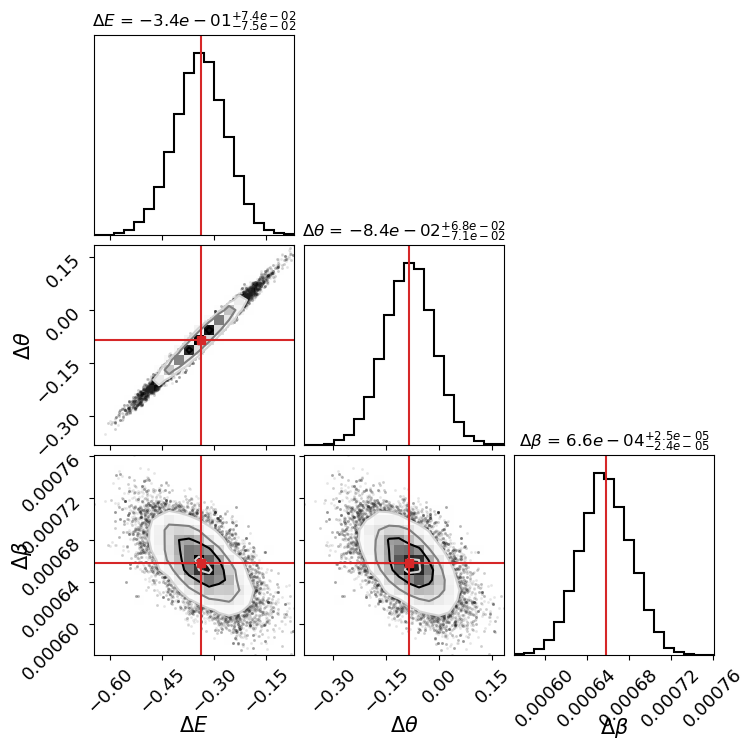

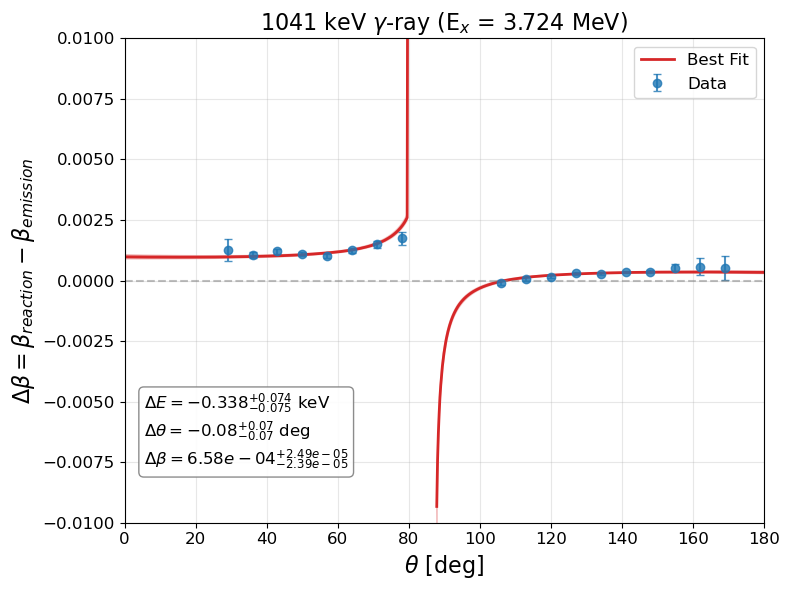


MCMC FIT RESULTS
Energy offset:  -338.222 +73.590 -74.703 keV
Angle offset:   -0.084 +0.068 -0.071 deg
Delta beta:     6.581e-04 +2.491e-05 -2.393e-05
Acceptance:     0.644


In [9]:
import emcee
import corner

# =========================
# MODEL: Doppler shift
# =========================
def doppler_model(theta_deg, energy_offset, angle_offset, delta_beta):
    beta1, beta2, theta_vals = calculate_doppler_beta(
        Eg0_val=gamma_energy,
        energy_offset=energy_offset,
        angle_offset=angle_offset,
        fixed_beta=beta_mean
    )

    doppler_betas = np.where(
        np.rad2deg(theta_vals) < 80,
        beta2 - beta_mean + delta_beta,
        beta1 - beta_mean + delta_beta
    )

    return np.interp(theta_deg, np.rad2deg(theta_vals), doppler_betas)

# =========================
# LIKELIHOOD + PRIORS
# =========================
def log_prior(theta):
    energy_offset, angle_offset, delta_beta = theta
    if -1000 < energy_offset < 1000 and -2 < angle_offset < 2 and -0.01 < delta_beta < 0.01:
        return 0.0
    return -np.inf

def log_likelihood(theta):
    energy_offset, angle_offset, delta_beta = theta
    # Mask where delta_beta_error is 0 to avoid division by zero
    mask = results['delta_beta_error'] > 0
    model = doppler_model(results['theta'][mask], energy_offset, angle_offset, delta_beta)
    chi2 = np.sum(((results['delta_beta'][mask] - model) / results['delta_beta_error'][mask])**2)
    return -0.5 * chi2

def log_posterior(theta):
    lp = log_prior(theta)
    return lp + log_likelihood(theta) if np.isfinite(lp) else -np.inf

# =========================
# RUN EMCEE
# =========================
p0 = np.array([0.0, 0.2, 1.3e-3])  # energy_offset, angle_offset, delta_beta

ndim = 3
nwalkers = 32
pos = p0 + 1e-5 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(pos, 3000, progress=True)

# =========================
# ANALYZE CHAIN
# =========================
burn = 2000
chain = sampler.get_chain(discard=burn, flat=True)

E_lo, E_med, E_hi = np.percentile(chain[:,0], [16, 50, 84])
A_lo, A_med, A_hi = np.percentile(chain[:,1], [16, 50, 84])
B_lo, B_med, B_hi = np.percentile(chain[:,2], [16, 50, 84])

# =========================
# UNCERTAINTY BAND
# =========================
theta_plot = np.linspace(0, 180, 800)
models = []

for s in chain[np.random.choice(len(chain), 300)]:
    models.append(doppler_model(theta_plot, *s))

models = np.array(models)
low, mid, high = np.percentile(models, [16, 50, 84], axis=0)

# =========================
# CORNER PLOT
# =========================
figure = corner.corner(
    chain, 
    labels=[r"$\Delta E$", r"$\Delta \theta$", r"$\Delta \beta$"], 
    truths=[E_med, A_med, B_med],
    show_titles=True,
    title_fmt=".1e",
    color='black',
    truth_color='tab:red',
    hist_kwargs={'color': '#0343df', 'edgecolor': 'black', 'linewidth': 1.5},
    contour_kwargs={'colors': ['lightgray', 'gray', 'black'], 'linewidths': 1.5}
)

for ax in figure.get_axes():
    ax.tick_params(labelsize=13)
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)

plt.show()

# =========================
# PLOT FIT
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(results['theta'], results['delta_beta'], yerr=results['delta_beta_error'], 
            fmt='o', color='tab:blue', label="Data", alpha=0.8, capsize=3)
ax.plot(theta_plot, mid, color='tab:red', lw=2, label="Best Fit")
ax.fill_between(theta_plot, low, high, color='tab:red', alpha=0.25)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlim(0, 180)
ax.set_ylim(-1e-2, 1e-2)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel(r"$\theta$ [deg]", fontsize=16)
ax.set_ylabel(r"$\Delta \beta = \beta _{reaction} - \beta _{emission}$", fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_title(f"{gamma_energy} keV $\\gamma$-ray (E$_x$ = {level_energy:.3f} MeV)", fontsize=16)


text = (rf"$\Delta E = {E_med:.3f}^{{+{(E_hi-E_med):.3f}}}_{{-{(E_med-E_lo):.3f}}}$ keV" "\n"
        rf"$\Delta \theta = {A_med:.2f}^{{+{A_hi-A_med:.2f}}}_{{-{A_med-A_lo:.2f}}}$ deg" "\n"
        rf"$\Delta \beta = {B_med:.2e}^{{+{B_hi-B_med:.2e}}}_{{-{B_med-B_lo:.2e}}}$")
ax.text(0.03, 0.27, text, transform=ax.transAxes, va='top',
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9), fontsize=12)

plt.tight_layout()
plt.savefig(f'plots/mcmc_doppler_fit_{gamma_energy}.png', dpi=150)
plt.show()

# =========================
# PRINT RESULTS
# =========================
print("\n" + "="*50)
print("MCMC FIT RESULTS")
print("="*50)
print(f"Energy offset:  {E_med*1e3:.3f} +{(E_hi-E_med)*1e3:.3f} -{(E_med-E_lo)*1e3:.3f} keV")
print(f"Angle offset:   {A_med:.3f} +{A_hi-A_med:.3f} -{A_med-A_lo:.3f} deg")
print(f"Delta beta:     {B_med:.3e} +{B_hi-B_med:.3e} -{B_med-B_lo:.3e}")
print(f"Acceptance:     {np.mean(sampler.acceptance_fraction):.3f}")
print("="*50)

  0%|          | 11/3000 [00:00<00:27, 107.88it/s]/Users/kuba/Desktop/15O Lifetime/Analysis/Lifetime/doppler.py:32: RuntimeWarning: invalid value encountered in sqrt
  discriminant = np.sqrt(1 + r2_cos2_theta - r2)
100%|██████████| 3000/3000 [00:48<00:00, 61.65it/s]


Best chi2: 1.99 at energy_offset=-0.216 keV, delta_beta=6.46e-04


100%|██████████| 3000/3000 [00:54<00:00, 54.77it/s] 


<Figure size 1000x800 with 0 Axes>

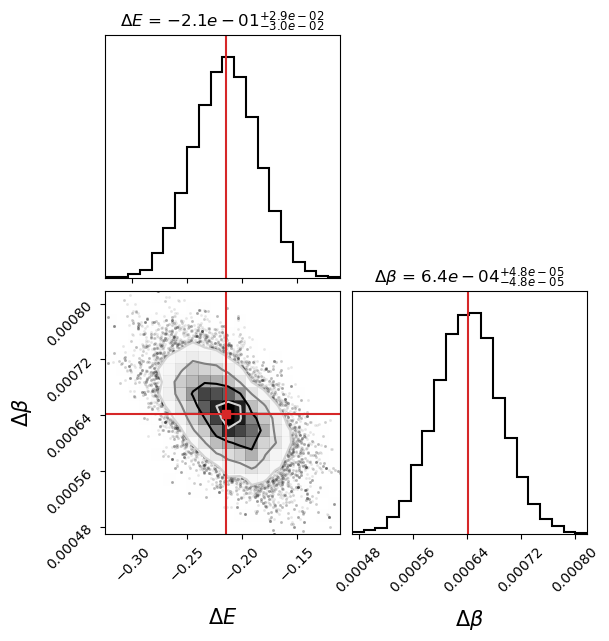

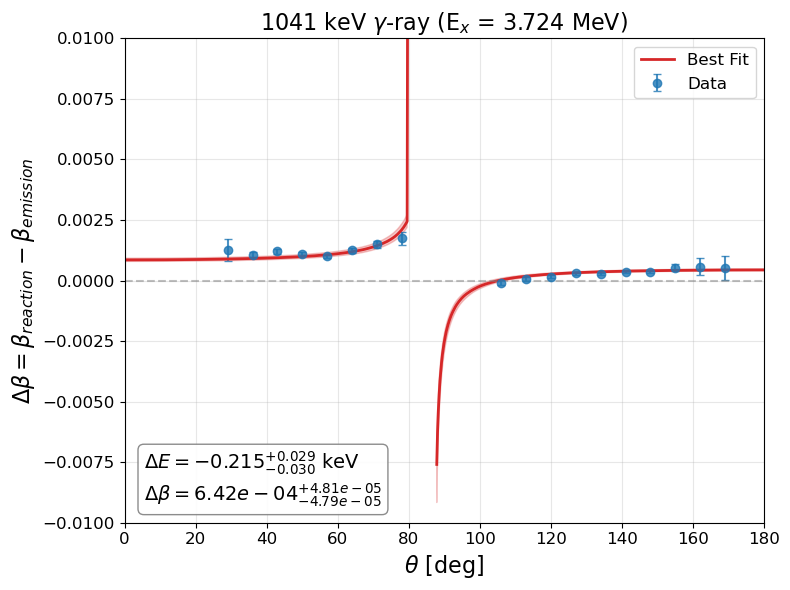


MCMC FIT RESULTS
Energy offset:  -214.679 +28.758 -29.679 keV
Delta beta:     6.423e-04 +4.808e-05 -4.793e-05
Acceptance:     0.715


In [10]:
import emcee
import corner

# Covariance matrix from bootstrap
cov = bootstrap_cov
cov_inv = np.linalg.inv(cov)

cov_inv = np.linalg.inv(cov)

# Scaling of chi2
scale_chi2 = 1

# =========================
# MODEL: Doppler shift
# =========================
def doppler_model(theta_deg, energy_offset, delta_beta):
    beta1, beta2, theta_vals = calculate_doppler_beta(
        Eg0_val=gamma_energy,
        energy_offset=energy_offset,
        angle_offset=0,
        fixed_beta=beta_mean
    )

    doppler_betas = np.where(
        np.rad2deg(theta_vals) < 80,
        beta2 - beta_mean + delta_beta,
        beta1 - beta_mean + delta_beta
    )

    return np.interp(theta_deg, np.rad2deg(theta_vals), doppler_betas)

# =========================
# LIKELIHOOD + PRIORS
# =========================
def log_prior(theta):
    energy_offset, delta_beta = theta
    if -1000 < energy_offset < 1000 and -0.01 < delta_beta < 0.01:
        # Add a normal norm prior for energy_offset centered at 0 with sigma of 200 keV
        lp = -0.5 * (energy_offset / 0.001)**2 * 0
        return lp
    return -np.inf

def log_likelihood(theta):
    energy_offset, delta_beta = theta
    
    mask = results['delta_beta_error'] > 0
    model = doppler_model(results['theta'][mask], energy_offset, delta_beta)
    residuals = results['delta_beta'][mask] - model
    
    # Full covariance chi2: r^T C^{-1} r
    chi2 = residuals @ cov_inv @ residuals
    return -0.5 * chi2 * scale_chi2

def log_posterior(theta):
    lp = log_prior(theta)
    return lp + log_likelihood(theta) if np.isfinite(lp) else -np.inf

# =========================
# RUN EMCEE
# =========================
p0 = np.array([0.0, 1.3e-4])  # energy_offset, delta_beta

ndim = 2
nwalkers = 32
pos = p0 + 1e-5 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(pos, 3000, progress=True)

# =========================
# ANALYZE CHAIN
# =========================
burn = 2000
chain = sampler.get_chain(discard=burn, flat=True)

E_lo, E_med, E_hi = np.percentile(chain[:,0], [16, 50, 84])
B_lo, B_med, B_hi = np.percentile(chain[:,1], [16, 50, 84])

# Print best chi2 value
log_prob = sampler.get_log_prob(discard=burn, flat=True)
best_idx = np.argmax(log_prob)
best_params = chain[best_idx]
best_chi2 = -2 * log_prob[best_idx] / len(results['theta'][results['delta_beta_error'] > 0])
print(f"Best chi2: {best_chi2:.2f} at energy_offset={best_params[0]:.3f} keV, delta_beta={best_params[1]:.2e}")
scale_chi2 = 1 / best_chi2

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(pos, 3000, progress=True)

burn = 2000
chain = sampler.get_chain(discard=burn, flat=True)

E_lo, E_med, E_hi = np.percentile(chain[:,0], [16, 50, 84])
B_lo, B_med, B_hi = np.percentile(chain[:,1], [16, 50, 84])

# =========================
# UNCERTAINTY BAND
# =========================
theta_plot = np.linspace(0, 180, 800)
models = []

for s in chain[np.random.choice(len(chain), 300)]:
    models.append(doppler_model(theta_plot, *s))

models = np.array(models)
low, mid, high = np.percentile(models, [16, 50, 84], axis=0)

# =========================
# CORNER PLOT
# =========================
figure = plt.figure(figsize=(10, 8))
figure = corner.corner(
    chain, 
    labels=[r"$\Delta E$", r"$\Delta \beta$"], 
    truths=[E_med, B_med],
    show_titles=True,
    title_fmt=".1e",
    color='black',
    truth_color='tab:red',
    label_kwargs={"fontsize": 15},
    hist_kwargs={'color': '#0343df', 'edgecolor': 'black', 'linewidth': 1.5},
    contour_kwargs={'colors': ['lightgray', 'gray', 'black'], 'linewidths': 1.5},
    figure=figure
)

figure.subplots_adjust(left=0.05, bottom=0.02)

plt.savefig(f'plots/mcmc_corner_{gamma_energy}.png', dpi=150)
plt.show()

# =========================
# PLOT FIT
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(results['theta'], results['delta_beta'], yerr=results['delta_beta_error'], 
            fmt='o', color='tab:blue', label="Data", alpha=0.8, capsize=3)
ax.plot(theta_plot, mid, color='tab:red', lw=2, label="Best Fit")
ax.fill_between(theta_plot, low, high, color='tab:red', alpha=0.25)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlim(0, 180)
ax.set_ylim(-1e-2, 1e-2)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel(r"$\theta$ [deg]", fontsize=16)
ax.set_ylabel(r"$\Delta \beta = \beta _{reaction} - \beta _{emission}$", fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_title(f"{gamma_energy} keV $\\gamma$-ray (E$_x$ = {level_energy:.3f} MeV)", fontsize=16)

text = (rf"$\Delta E = {E_med:.3f}^{{+{(E_hi-E_med):.3f}}}_{{-{(E_med-E_lo):.3f}}}$ keV" "\n"
        rf"$\Delta \beta = {B_med:.2e}^{{+{B_hi-B_med:.2e}}}_{{-{B_med-B_lo:.2e}}}$")
ax.text(0.03, 0.15, text, transform=ax.transAxes, va='top',
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9), fontsize=14)

plt.tight_layout()
plt.savefig(f'plots/mcmc_doppler_fit_{gamma_energy}.png', dpi=150)
plt.show()

# =========================
# PRINT RESULTS
# =========================
print("\n" + "="*50)
print("MCMC FIT RESULTS")
print("="*50)
print(f"Energy offset:  {E_med*1e3:.3f} +{(E_hi-E_med)*1e3:.3f} -{(E_med-E_lo)*1e3:.3f} keV")
print(f"Delta beta:     {B_med:.3e} +{(B_hi-B_med):.3e} -{B_med-B_lo:.3e}")
print(f"Acceptance:     {np.mean(sampler.acceptance_fraction):.3f}")
print("="*50)